In [16]:
import pandas as pd
import numpy as np
from Carl_Response_Functions.load_responses import norm, readCsv
from Carl_Response_Functions.first_level_GLM import *
from Carl_Response_Functions.classification import *
from Carl_Response_Functions.plotting import labelGraph, get_plot_low_pain_subjects
import matplotlib.pyplot as plt


In [17]:
responses = readCsv("responseArray.csv")
responses_df = pd.read_csv('Carl_preprocessed_responses/preprocessed_response_details.csv', sep='\t')
z_maps_path = "Carl_first_level_z_maps_resampled_mask_2"

participants_df = pd.read_csv('openpain.org/subacute_longitudinal_study/participants.tsv', sep='\t')
subacute_df = participants_df.loc[participants_df["group"] == "subacute"]
chronic_df = participants_df.loc[participants_df["group"] == "chronic"]

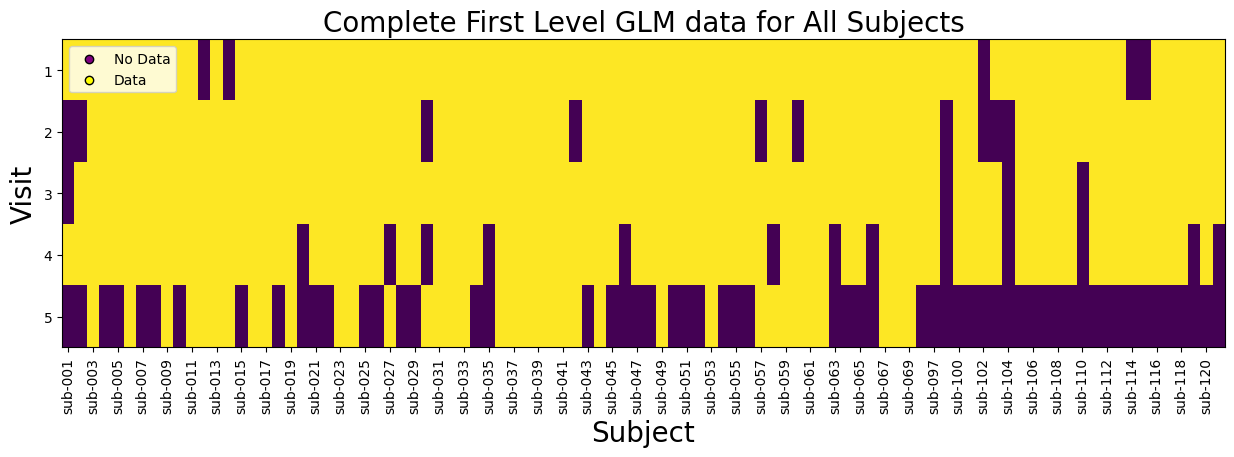

In [18]:
visitsDf, subjects = plot_grid_of_first_level_GLMs(z_maps_path)

In [19]:
visitsDf.to_csv('Carl_first_level_z_maps_resampled_mask_2/visitsGrid.csv', sep='\t')

## Old classification Method

41 persisting subjects
29 recovering subjects


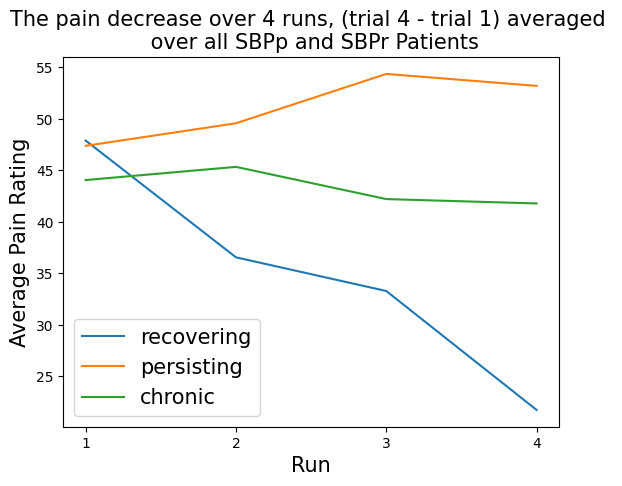

In [20]:
responses_df = basic_classify_subacute_and_chronic(responses_df)
responses_df.to_csv('Carl_preprocessed_responses/preprocessed_response_details.csv', sep='\t', index=None)

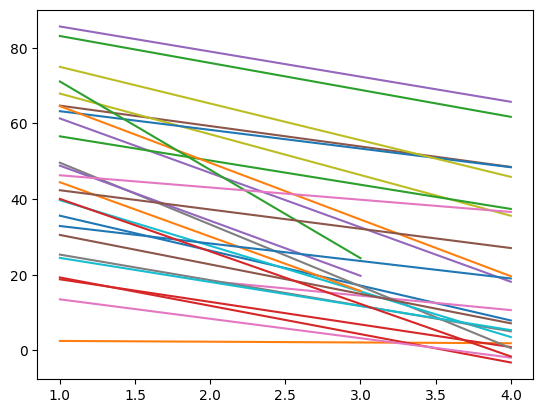

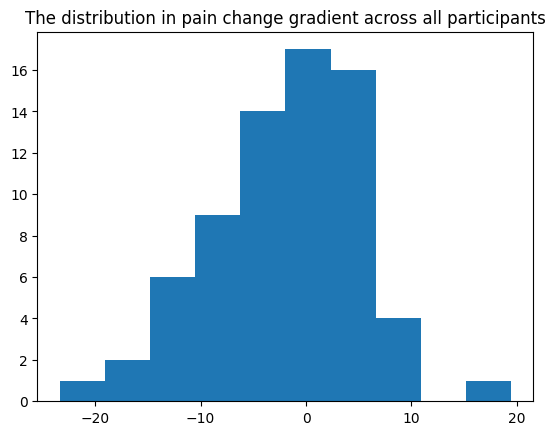

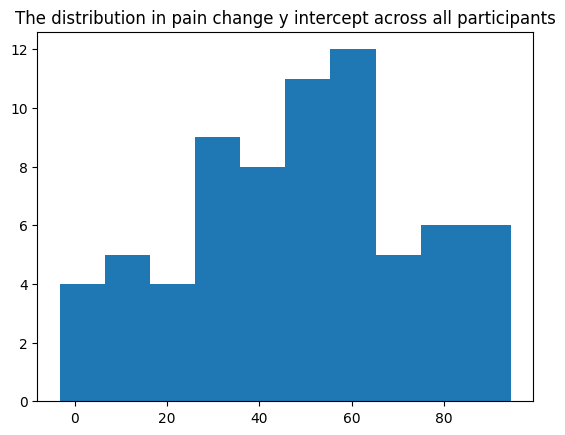

43 persisting subjects
27 recovering subjects


In [21]:
responses_df = compute_classifications_for_all_subjects(responses_df)
#responses_df.to_csv('Carl_preprocessed_responses/preprocessed_response_details.csv', sep='\t', index=None)
print(len(set(list(responses_df.loc[responses_df['classification'] == 'SBPp']['subject']))), "persisting subjects")
print(len(set(list(responses_df.loc[responses_df['classification'] == 'SBPr']['subject']))), "recovering subjects")

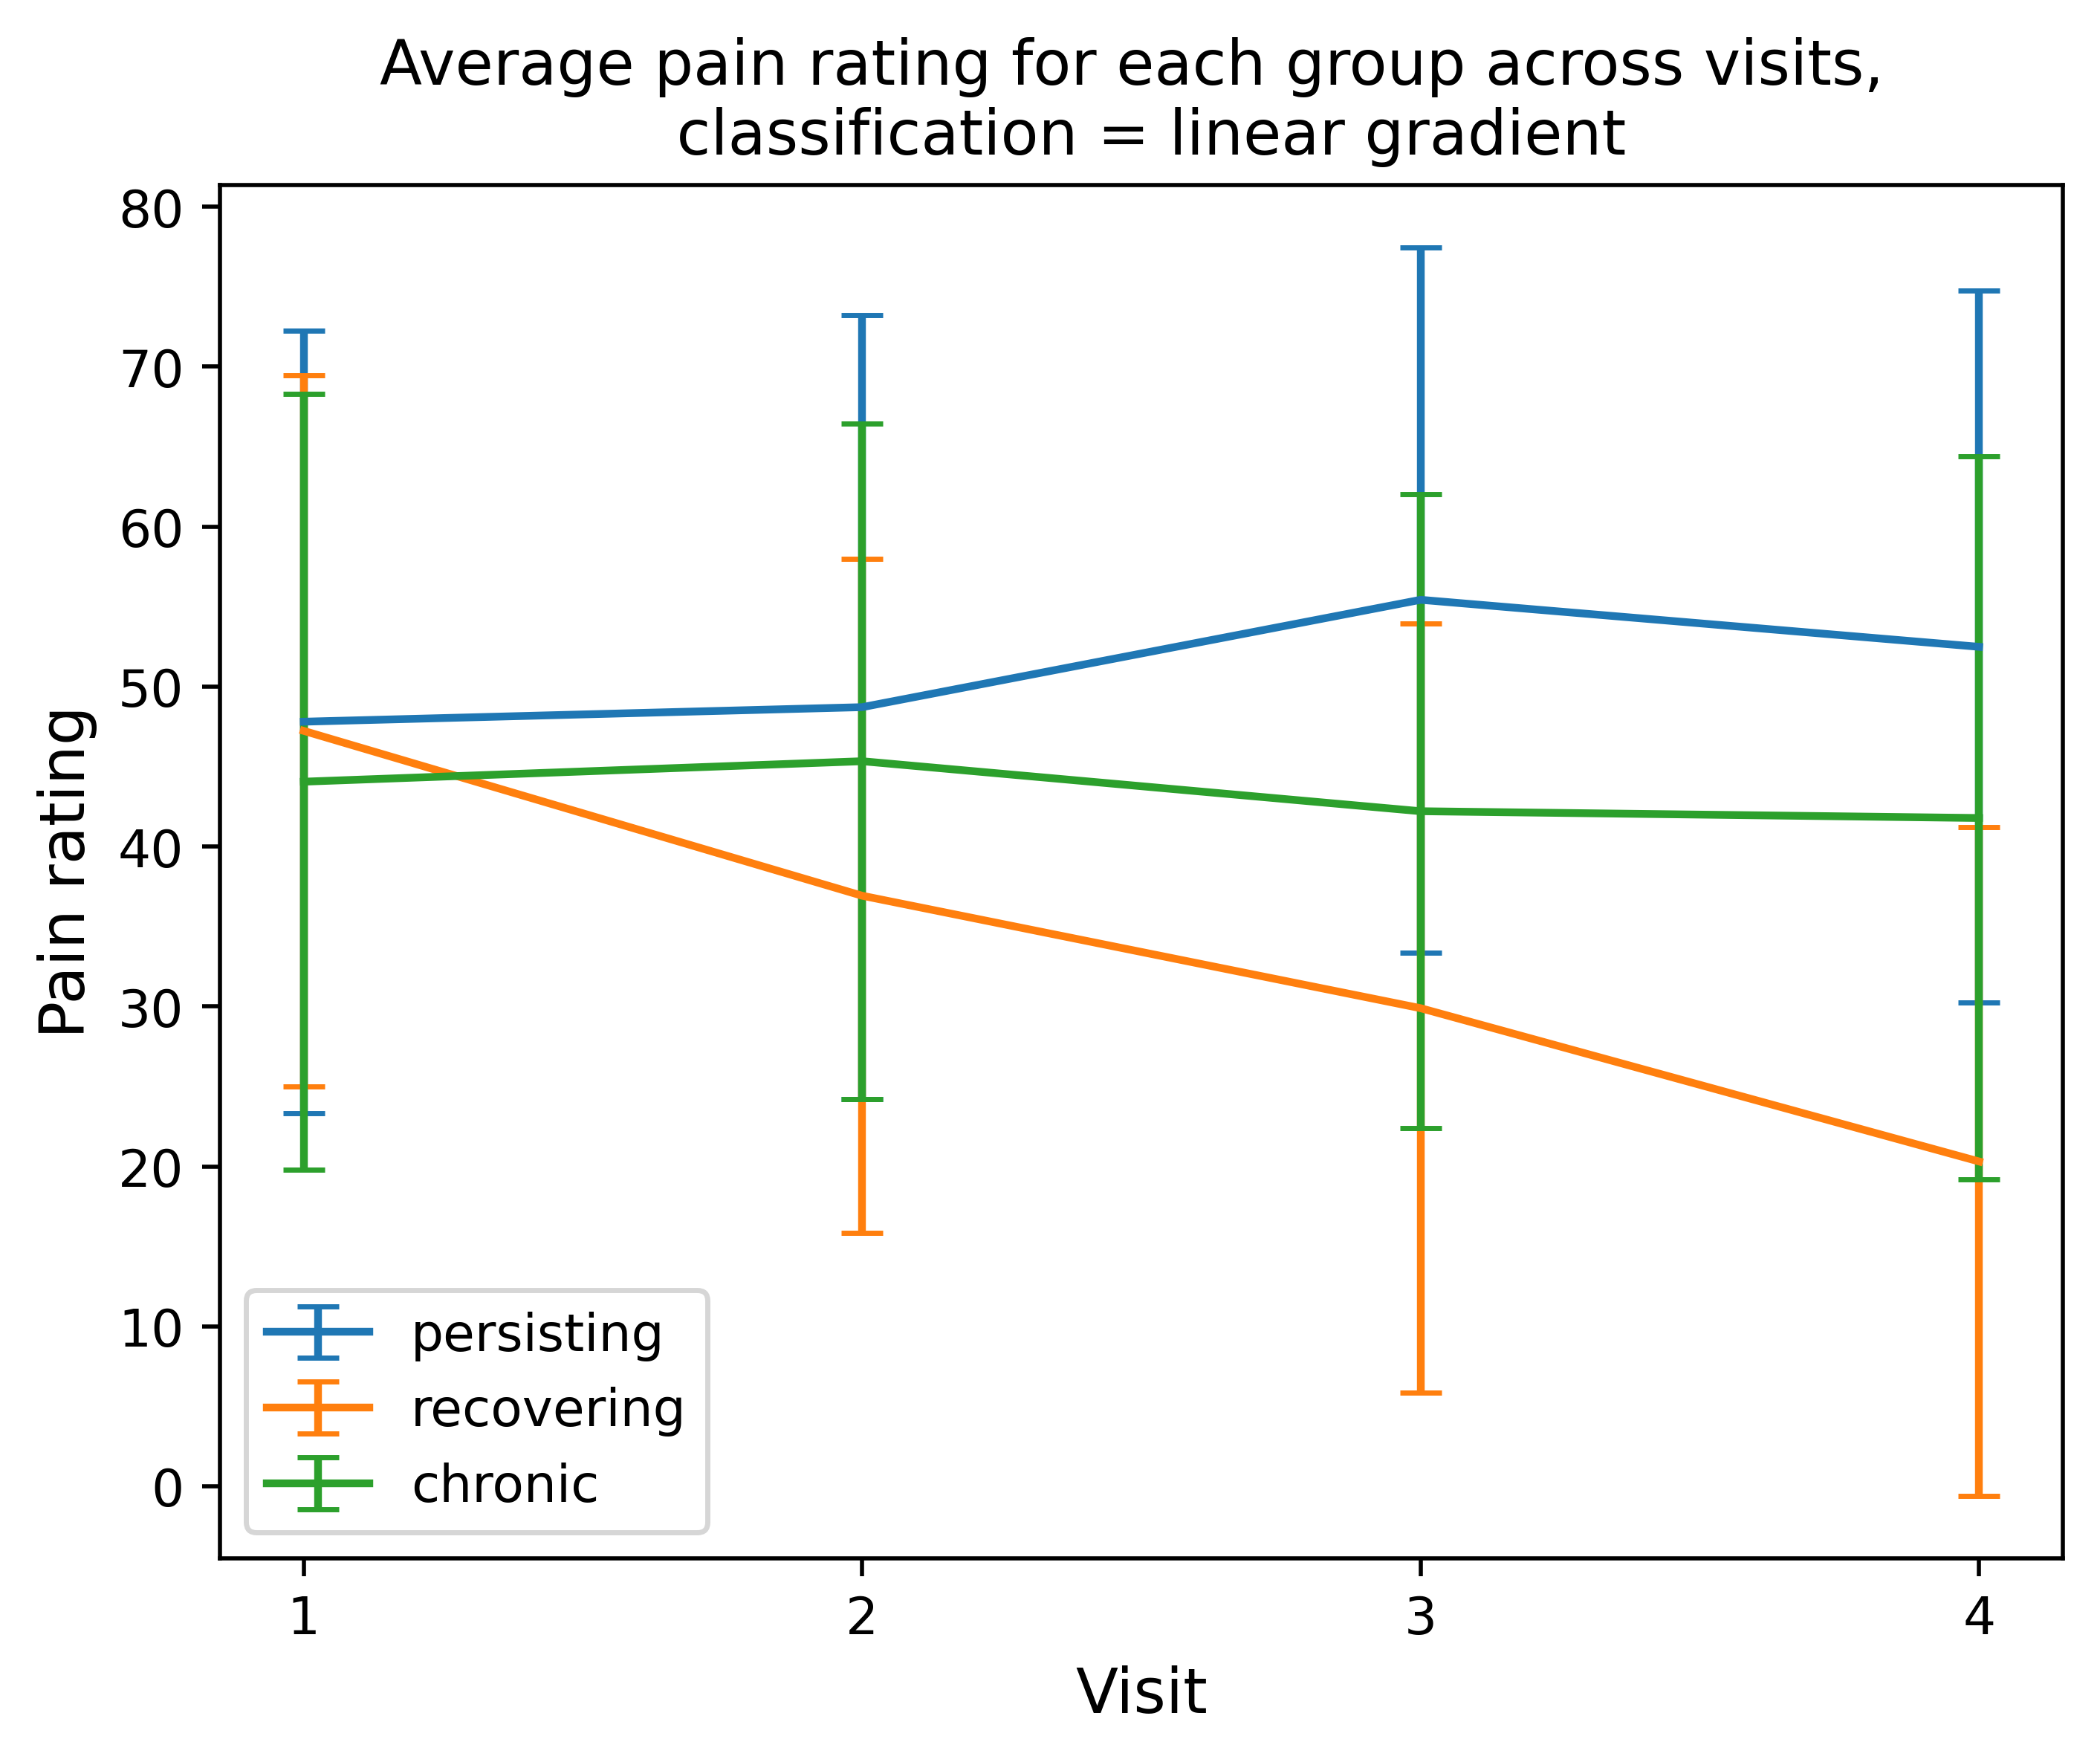

In [22]:
plot_averages_across_visits(responses_df)

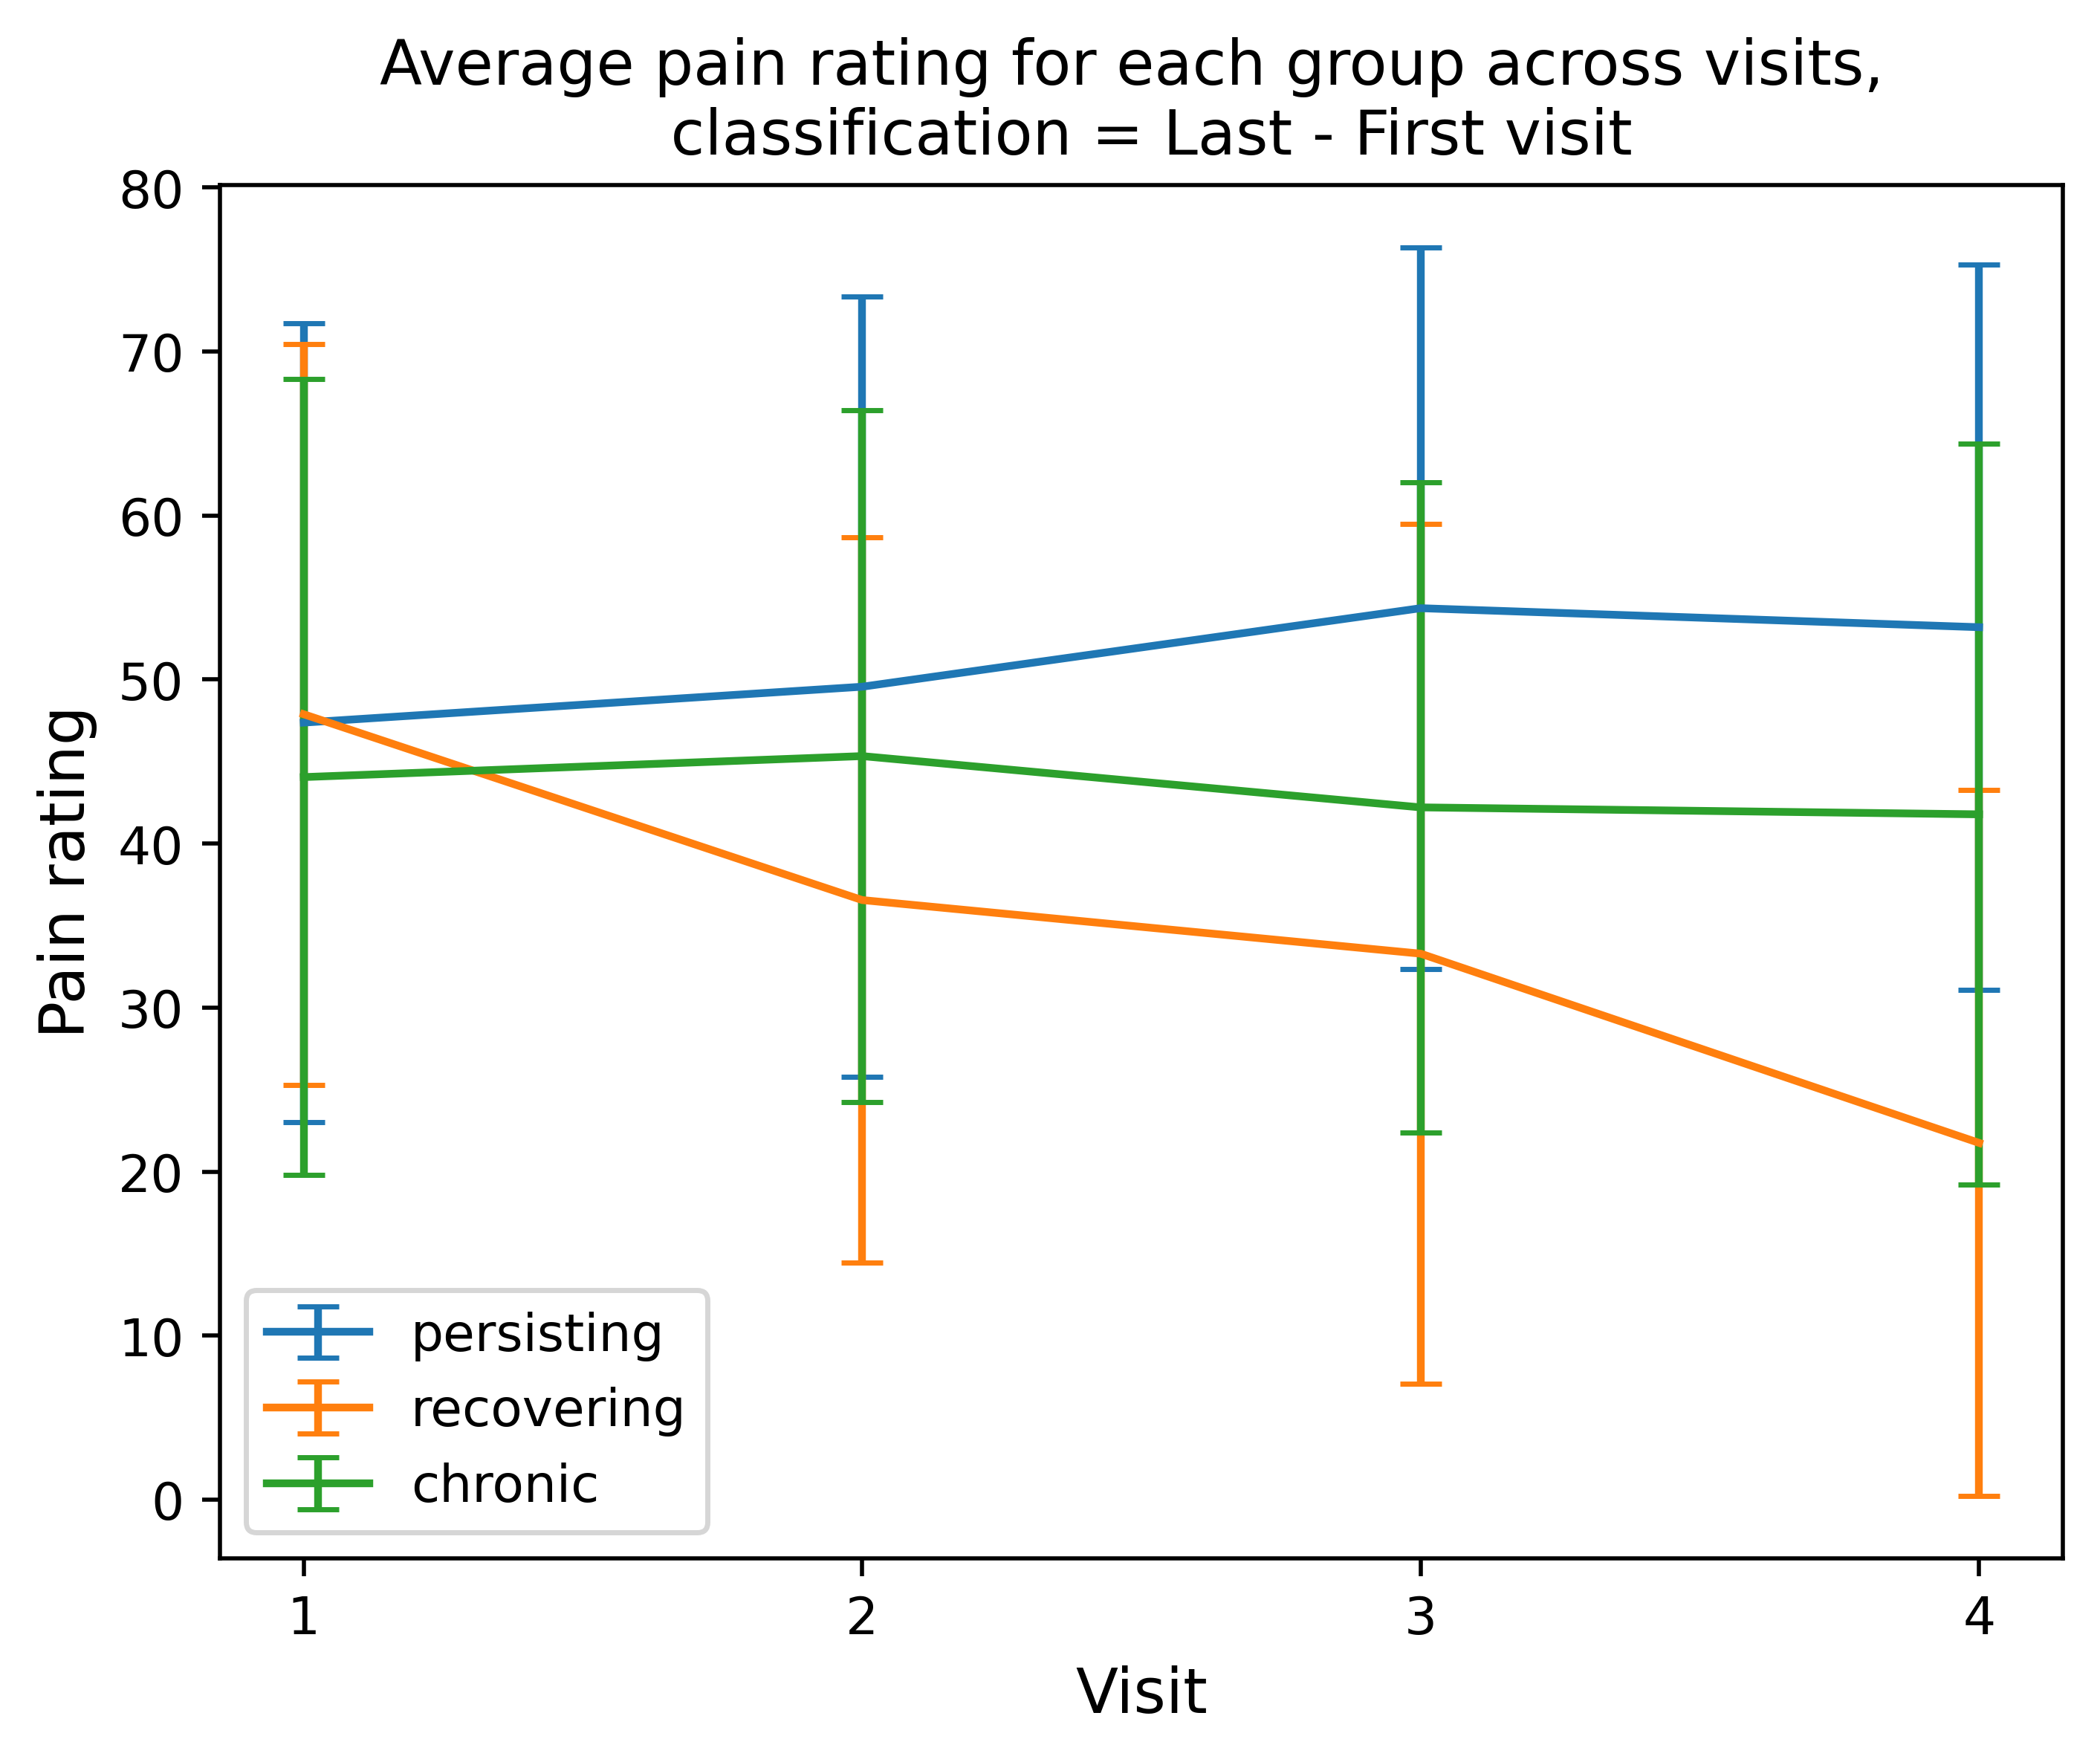

In [23]:
plot_averages_across_visits(responses_df,classType='basicClassification')

# Comparing the two types of classification

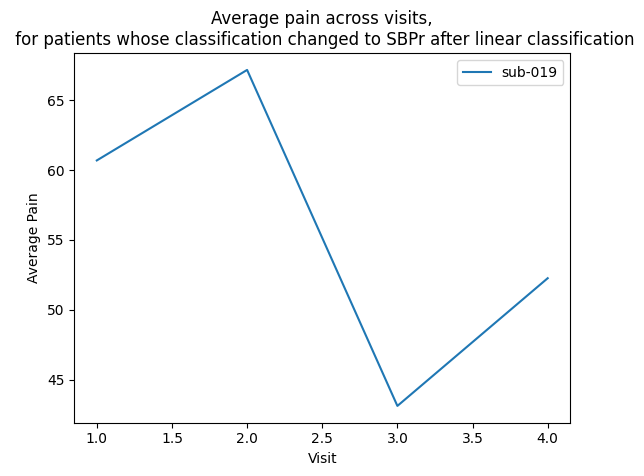

In [24]:
pd.set_option('display.min_rows', 100)
pd.set_option('display.max_rows', 200)
changingSubjects = set(list(responses_df[(responses_df['classification']== 'SBPr') & (responses_df['basicClassification'] == 'SBPp')]['subject']))


plot_the_changing_subjects(responses_df,changingSubjects, title="Average pain across visits,\n for patients whose classification changed to SBPr after linear classification")


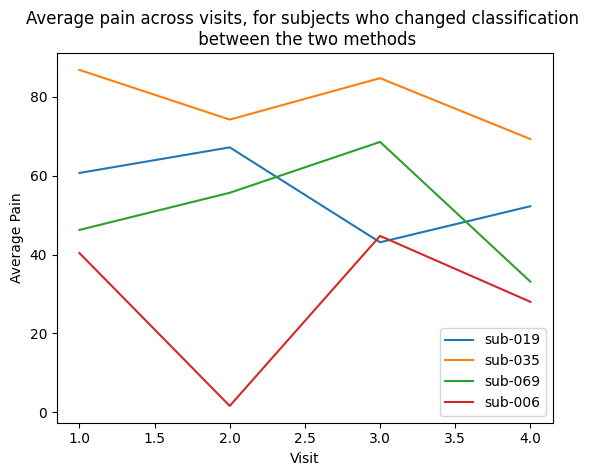

In [25]:
changingSubjects = set(list(responses_df[responses_df['classification'] != responses_df['basicClassification']]['subject']))

plot_the_changing_subjects(responses_df,changingSubjects,
  title="Average pain across visits, for subjects who changed classification \n between the two methods")

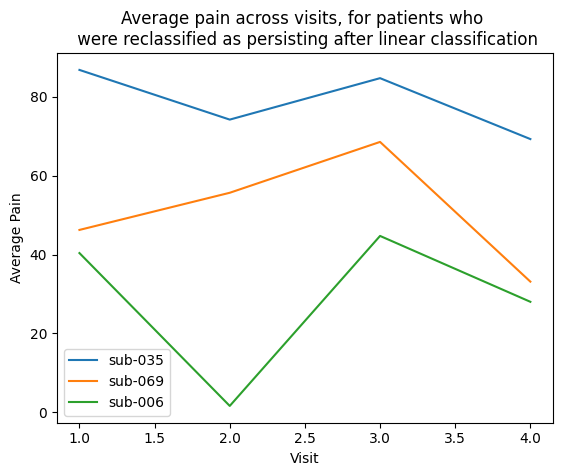

In [26]:

changingSubjects = set(list(responses_df[(responses_df['classification']== 'SBPp') & (responses_df['basicClassification'] == 'SBPr')]['subject']))

plot_the_changing_subjects(responses_df,changingSubjects,title="Average pain across visits, for patients who \n were reclassified as persisting after linear classification")

# Removing pain ratings which do not have enough variability to work with

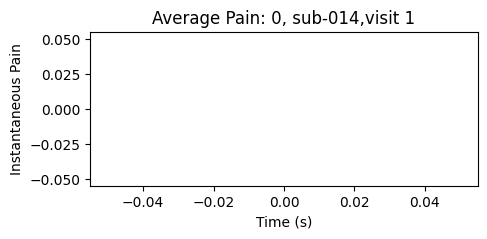

In [27]:
painRatingArray = readCsv('responseArray.csv')
index = responses_df.loc[(responses_df['subject'] == 'sub-014') & (responses_df['visit'] == f'visit1')].index
labelGraph(painRatingArray[index].T,0,'sub-014', "visit 1")

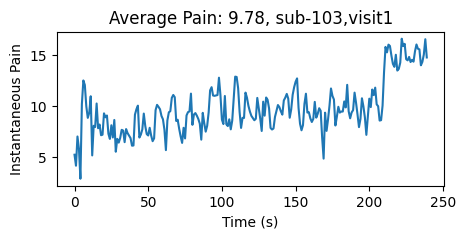

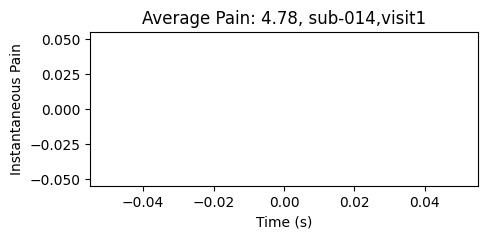

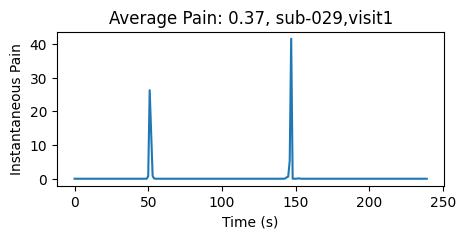

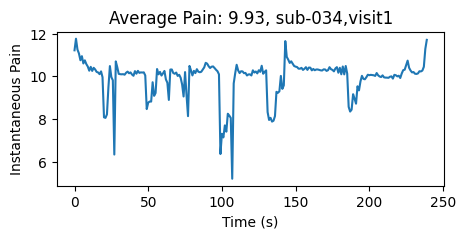

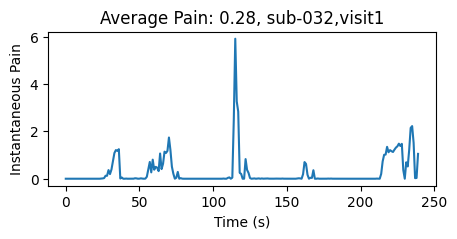

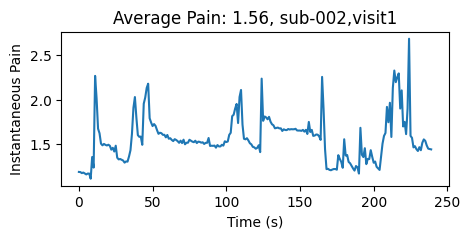

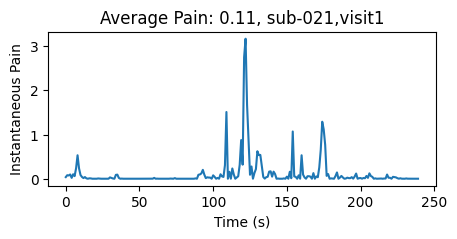

['sub-103', 'sub-014', 'sub-029', 'sub-034', 'sub-032', 'sub-002', 'sub-021']


In [28]:
#57 did not have all runs
all_subjects = set(list(responses_df['subject']))
lowPainSubjects = get_plot_low_pain_subjects(responses_df, responses,all_subjects, plot=True, threshold=10)
print(lowPainSubjects)

In [29]:
REMOVE = visitsDf[(visitsDf['visit1'] == False) | (visitsDf['visit4'] == False)]
print(REMOVE)
REMOVE = REMOVE.index

removeSubjects = []
removeSubjects.extend(list(REMOVE))
removeSubjects.extend(list(lowPainSubjects))
removeSubjects = list(set(removeSubjects))
print(sorted(removeSubjects))
print(len(removeSubjects))


         visit1  visit2  visit3  visit4  visit5
sub-012   False    True    True    True    True
sub-014   False    True    True    True    True
sub-020    True    True    True   False   False
sub-027    True    True    True   False    True
sub-030    True   False    True   False    True
sub-035    True    True    True   False   False
sub-046    True    True    True   False   False
sub-058    True    True    True   False    True
sub-063    True    True    True   False   False
sub-066    True    True    True   False   False
sub-099    True   False   False   False   False
sub-102   False   False    True    True   False
sub-104    True   False   False   False   False
sub-110    True    True   False   False   False
sub-114   False    True    True    True   False
sub-115   False    True    True    True   False
sub-119    True    True    True   False   False
sub-121    True    True    True   False   False
['sub-002', 'sub-012', 'sub-014', 'sub-020', 'sub-021', 'sub-027', 'sub-029', 'sub-030',

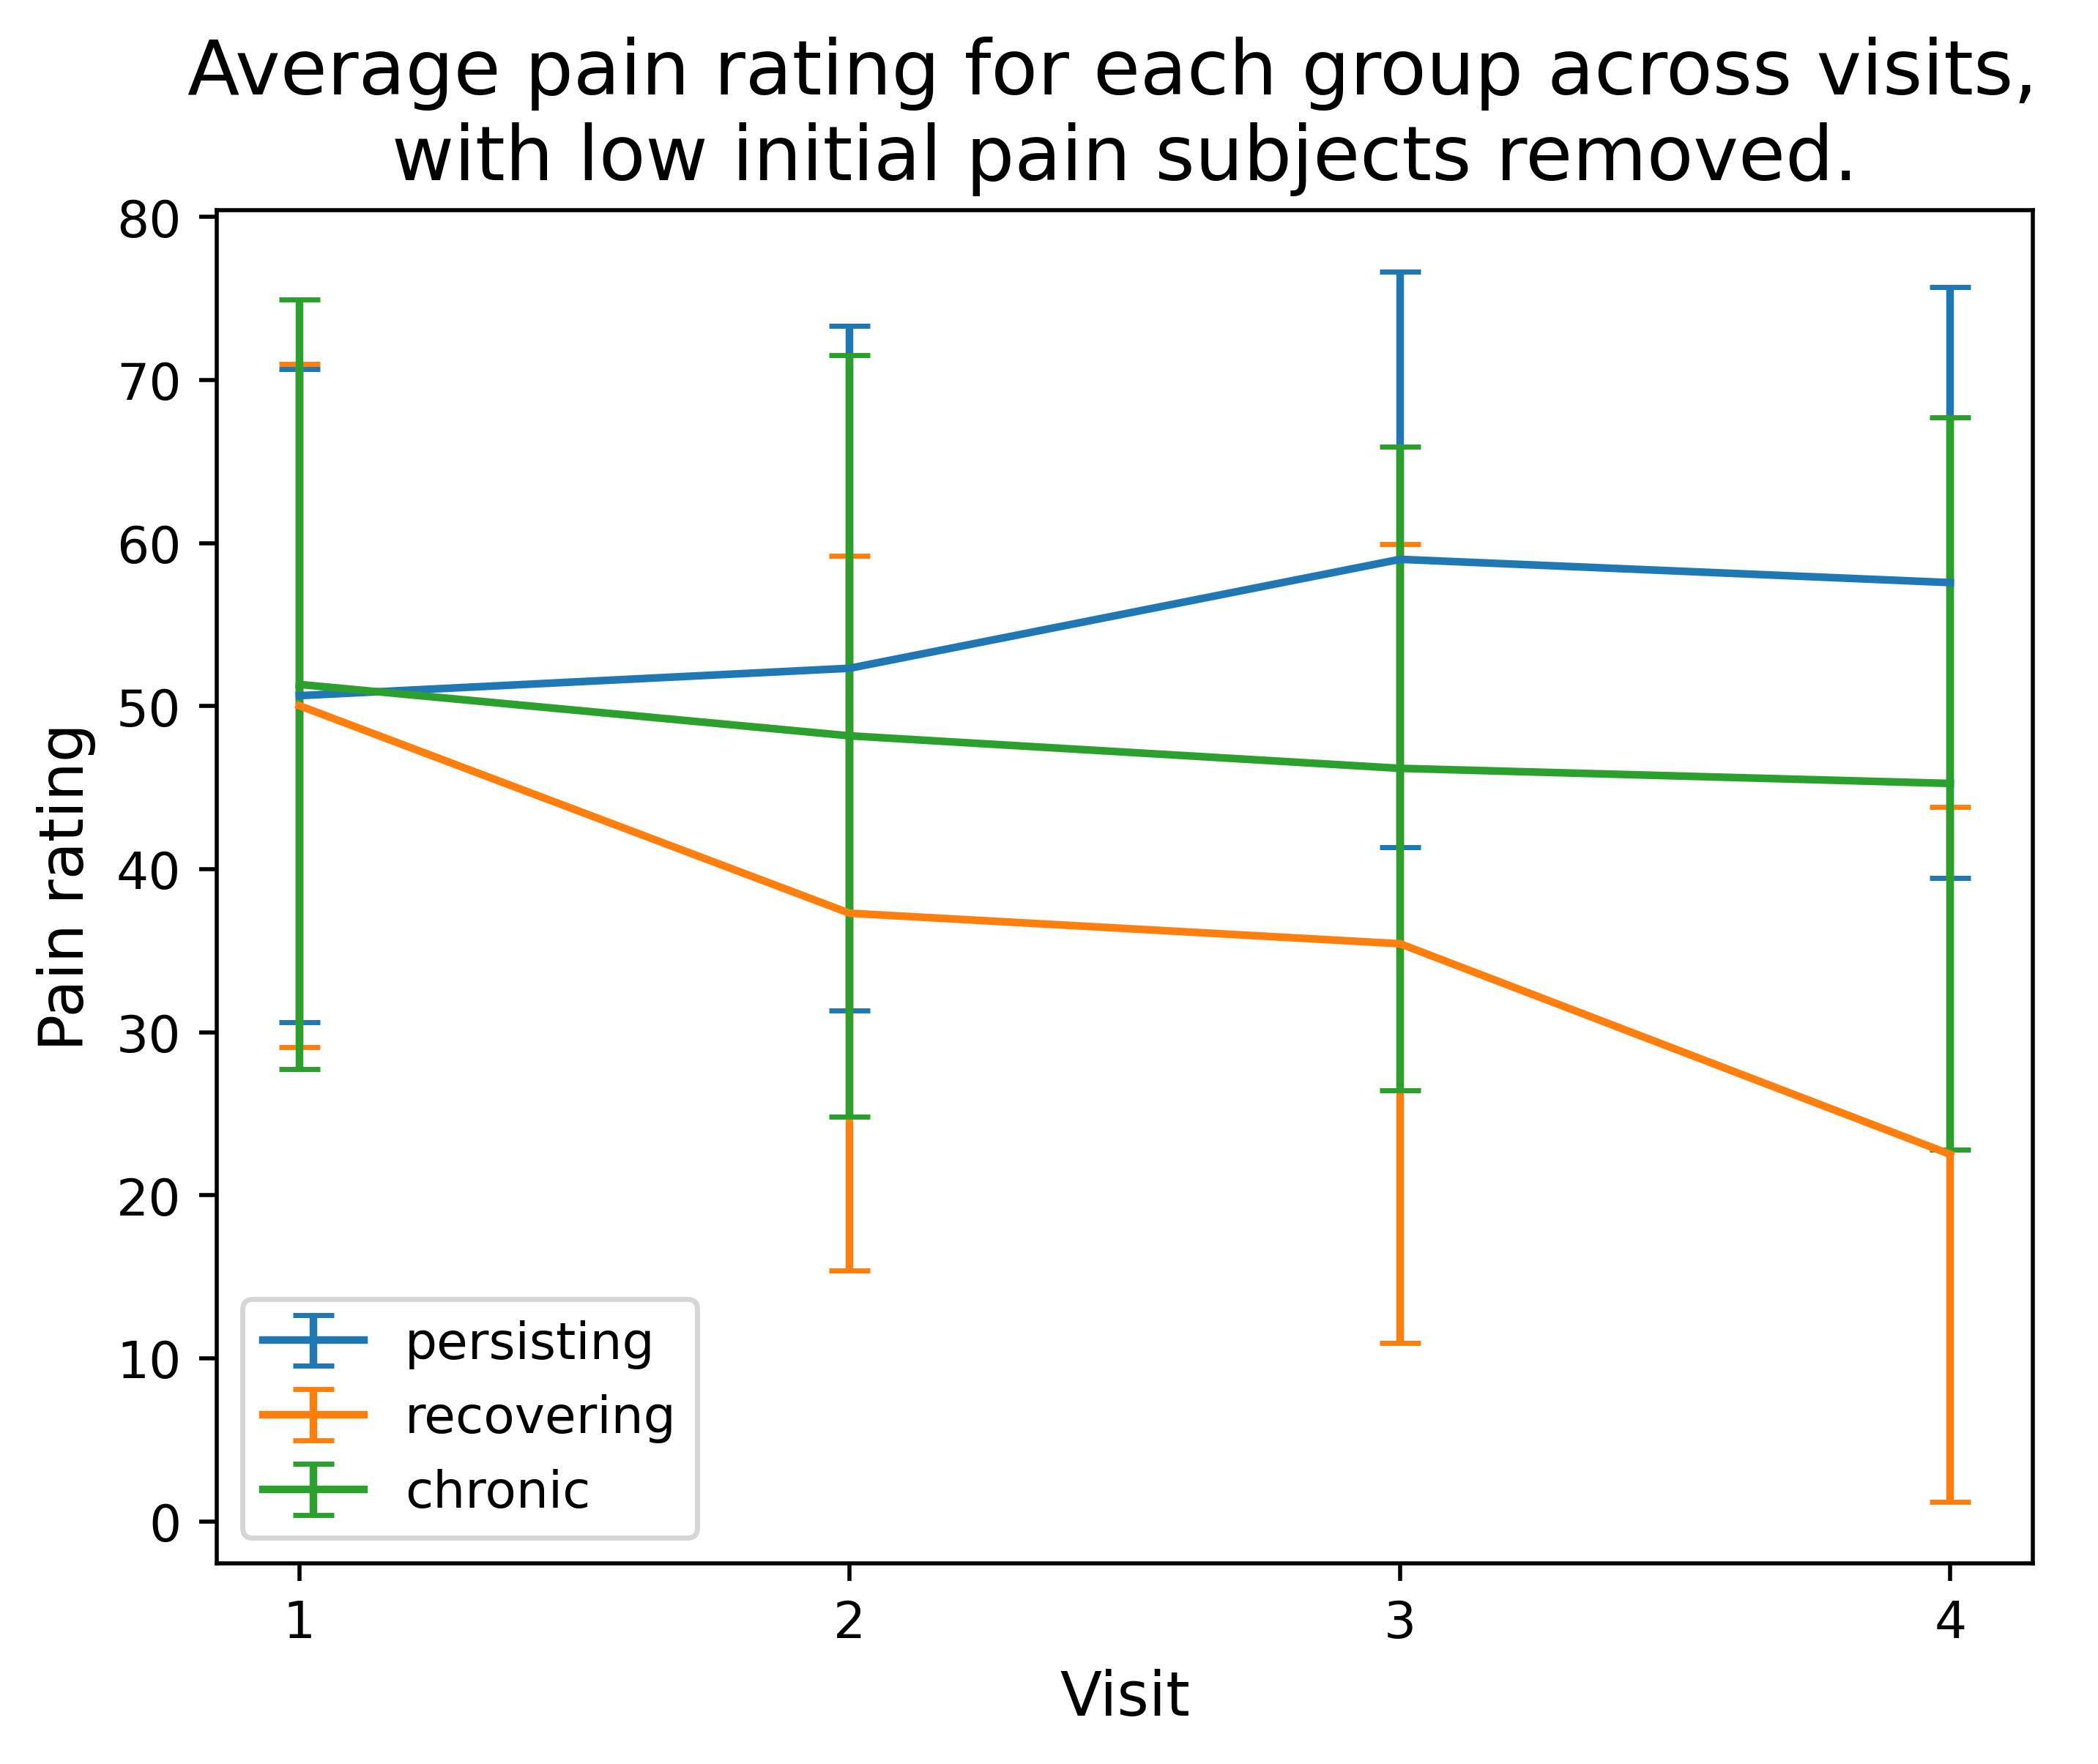

In [31]:
plot_averages_across_visits(responses_df,classType='classification', subjectsToRemove = removeSubjects,title="Average pain rating for each group across visits, \nwith low initial pain subjects removed.")

# Adding interview Times

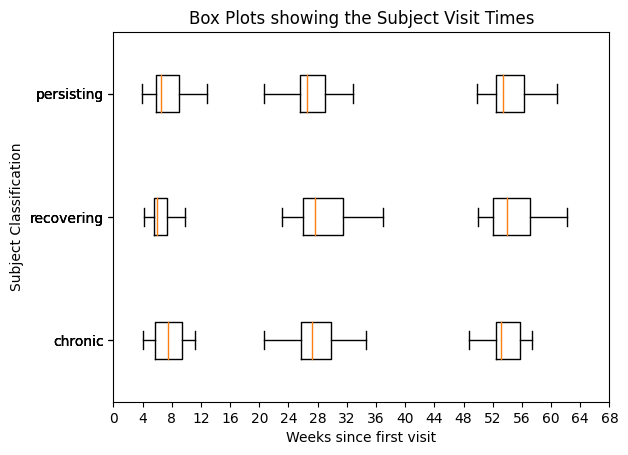

In [32]:
persisting = responses_df.loc[responses_df['classification'] == 'SBPp']['subject']
recovering = responses_df.loc[responses_df['classification'] == 'SBPr']['subject']


interview_times = np.zeros((len(participants_df),6))
for index, participant in enumerate(participants_df['participant_id']):
  # if participant != "sub-001":
  #   continue
  sessions_df = pd.read_csv(f"openpain.org/subacute_longitudinal_study/{participant}/{participant}_sessions.tsv", sep='\t')
  interview_times[index,:len(sessions_df['days_since_interview'])] = sessions_df['days_since_interview']

#participants start at sub-001
# Create lists to hold the data for each category
means = np.zeros((4,3))
for i in range(2,5):
  group0 = []
  group1 = []
  group2 = []
  data_for_boxplot = []
  for j, subject in enumerate(chronic_df['participant_id']):
    time = interview_times[int(subject[-3:])-1,i] - interview_times[int(subject[-3:])-1,1]
    if str(time) != "nan":
      group0.append(time)

  for j, subject in enumerate(recovering):
    time = interview_times[int(subject[-3:])-1,i] - interview_times[int(subject[-3:])-1,1]
    if str(time) != "nan":
      group1.append(time)

  for j, subject in enumerate(persisting):
    time = interview_times[int(subject[-3:])-1,i] - interview_times[int(subject[-3:])-1,1]
    if str(time) != "nan":
      group2.append(time)

  data_for_boxplot = [group0, group1, group2]
  means[i-2] = [np.mean(group0), np.mean(group1), np.mean(group2)]
  plt.boxplot(data_for_boxplot, vert=False, notch=False, sym='',labels=['chronic', 'recovering','persisting'])
  
# Set the y-axis label
plt.ylabel('Subject Classification')

plt.xlabel("Weeks since first visit")
plt.xticks(np.arange(0,70,4)*7,np.arange(0,70,4))

# Set the title of the plot
plt.title('Box Plots showing the Subject Visit Times')

# Display the plot

plt.show()


# Testing significant Pain level Differences in visit 4

In [33]:
pd.set_option('display.min_rows', 10)
pd.set_option('display.max_rows', 20)
responses_df

,subject,visit,run,group,average_pain,classification,basicClassification
0,sub-001,visit1,run_01,subacute,38.132750,SBPr,SBPr
1,sub-001,visit2,run_01,subacute,22.580528,SBPr,SBPr
2,sub-001,visit4,run_01,subacute,9.183889,SBPr,SBPr
3,sub-002,visit1,run_01,subacute,1.564784,SBPr,SBPr
4,sub-002,visit3,run_01,subacute,4.957028,SBPr,SBPr
...,...,...,...,...,...,...,...
385,sub-120,visit3,run_01,chronic,63.868828,chronic,chronic
386,sub-120,visit4,run_01,chronic,65.114483,chronic,chronic
387,sub-121,visit1,run_01,chronic,30.701192,chronic,chronic
388,sub-121,visit2,run_01,chronic,34.913745,chronic,chronic


In [34]:
from scipy.stats import ttest_ind
def t_test(recoveringMeans, persistingMeans):
  group1 = recoveringMeans['average_pain']
  group2 = persistingMeans['average_pain']
  plt.hist(group1,label= 'recovering',bins=20)
  plt.hist(group2,label='persisting',color=(0.5,0.1,0.9,0.5),bins=20)
  plt.legend()
  plt.show()

  # perform t-test
  t_statistic, p_value = ttest_ind(group1, group2)

  # print the results
  print("t-statistic:", t_statistic)
  print("p-value:", p_value)

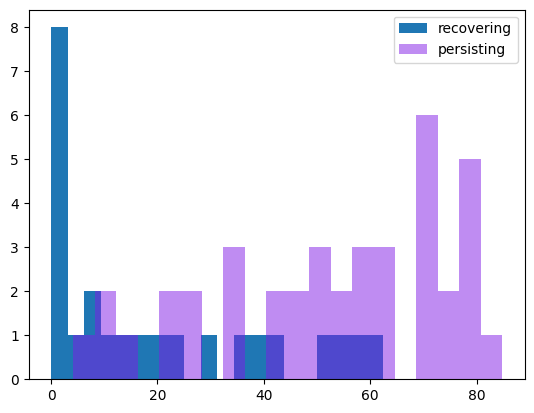

t-statistic: -5.638234320769509
p-value: 4.506969344959421e-07


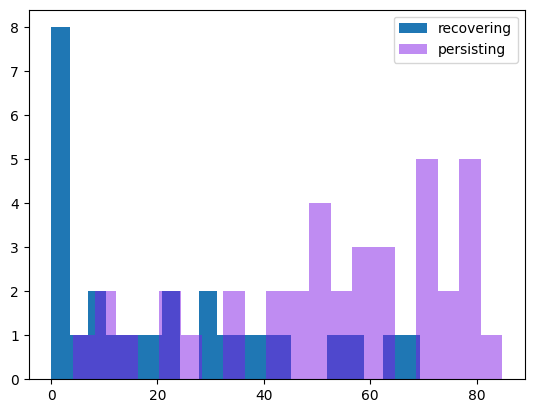

t-statistic: -5.563320042476078
p-value: 6.003813357710364e-07


In [35]:
recoveringMeans = responses_df[(responses_df['classification'] == 'SBPr') & (responses_df['visit'] == 'visit4')]
persistingMeans = responses_df[(responses_df['classification'] == 'SBPp') & (responses_df['visit'] == 'visit4')]

t_test(recoveringMeans, persistingMeans)

recoveringMeans = responses_df[(responses_df['basicClassification'] == 'SBPr') & (responses_df['visit'] == 'visit4')]
persistingMeans = responses_df[(responses_df['basicClassification'] == 'SBPp') & (responses_df['visit'] == 'visit4')]

t_test(recoveringMeans, persistingMeans)
